# 🫁 Lung Cancer Risk Prediction
Predicting patient cancer risk levels (**Low**, **Medium**, **High**) using clinical symptoms and lifestyle features.
- **Task:** Multi-class Classification
- **Target:** `Level` (0: Low, 1: Medium, 2: High)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Data Loading & Exploration
Loading patient data, inspecting columns, shapes, and summary statistics.

In [2]:
df=pd.read_csv("../data/cancer patient data sets.csv")
df.head()

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [3]:
df.columns.to_list()

['index',
 'Patient Id',
 'Age',
 'Gender',
 'Air Pollution',
 'Alcohol use',
 'Dust Allergy',
 'OccuPational Hazards',
 'Genetic Risk',
 'chronic Lung Disease',
 'Balanced Diet',
 'Obesity',
 'Smoking',
 'Passive Smoker',
 'Chest Pain',
 'Coughing of Blood',
 'Fatigue',
 'Weight Loss',
 'Shortness of Breath',
 'Wheezing',
 'Swallowing Difficulty',
 'Clubbing of Finger Nails',
 'Frequent Cold',
 'Dry Cough',
 'Snoring',
 'Level']

In [4]:
df.shape

(1000, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

In [6]:
df.describe()

,index,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
count,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,37.174000,1.402000,3.8400,4.563000,5.165000,4.840000,4.580000,4.380000,4.491000,...,4.859000,3.856000,3.855000,4.240000,3.777000,3.746000,3.923000,3.536000,3.853000,2.926000
std,288.819436,12.005493,0.490547,2.0304,2.620477,1.980833,2.107805,2.126999,1.848518,2.135528,...,2.427965,2.244616,2.206546,2.285087,2.041921,2.270383,2.388048,1.832502,2.039007,1.474686
min,0.000000,14.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,249.750000,27.750000,1.000000,2.0000,2.000000,4.000000,3.000000,2.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,499.500000,36.000000,1.000000,3.0000,5.000000,6.000000,5.000000,5.000000,4.000000,4.000000,...,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,749.250000,45.000000,2.000000,6.0000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,...,7.000000,5.000000,6.000000,6.000000,5.000000,5.000000,5.000000,5.000000,6.000000,4.000000
max,999.000000,73.000000,2.000000,8.0000,8.000000,8.000000,8.000000,7.000000,7.000000,7.000000,...,9.000000,9.000000,8.000000,9.000000,8.000000,8.000000,9.000000,7.000000,7.000000,7.000000


In [7]:
df.isnull().sum()

index                       0
Patient Id                  0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
dtype: int64

In [8]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
df["Level"].value_counts()

Level
High      365
Medium    332
Low       303
Name: count, dtype: int64

In [10]:
df["Gender"].value_counts()

Gender
1    598
2    402
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA)
Visualizing feature distributions and risk factors across patient groups.


C:\Users\Funda\AppData\Local\Temp\ipykernel_9380\3472520515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( x="Level" , y="Age", data=df , palette="flare")


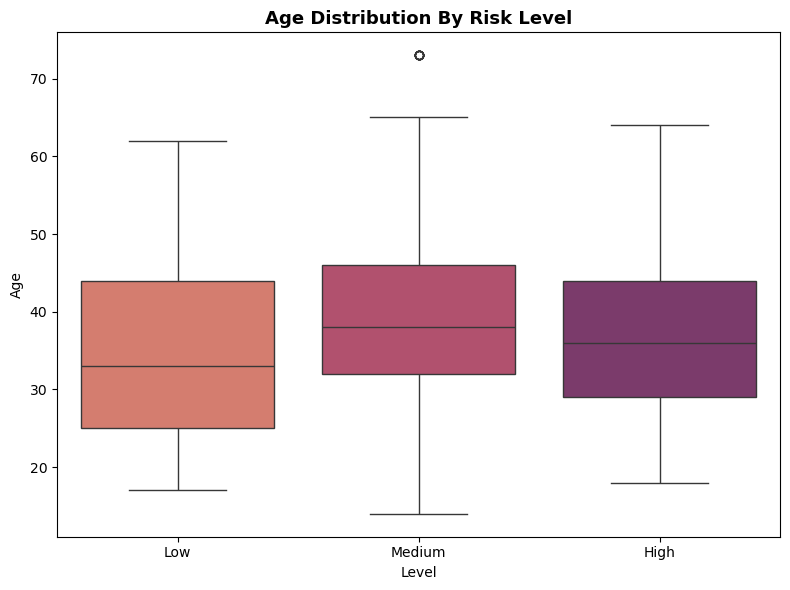

In [11]:
plt.figure(figsize=(8,6))
sns.boxplot( x="Level" , y="Age", data=df , palette="flare")
plt.title("Age Distribution By Risk Level" , fontsize=13 , fontweight="bold")
plt.xlabel("Level")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

C:\Users\Funda\AppData\Local\Temp\ipykernel_9380\3147302541.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x="Level" , y="Smoking", data=df , palette="flare")


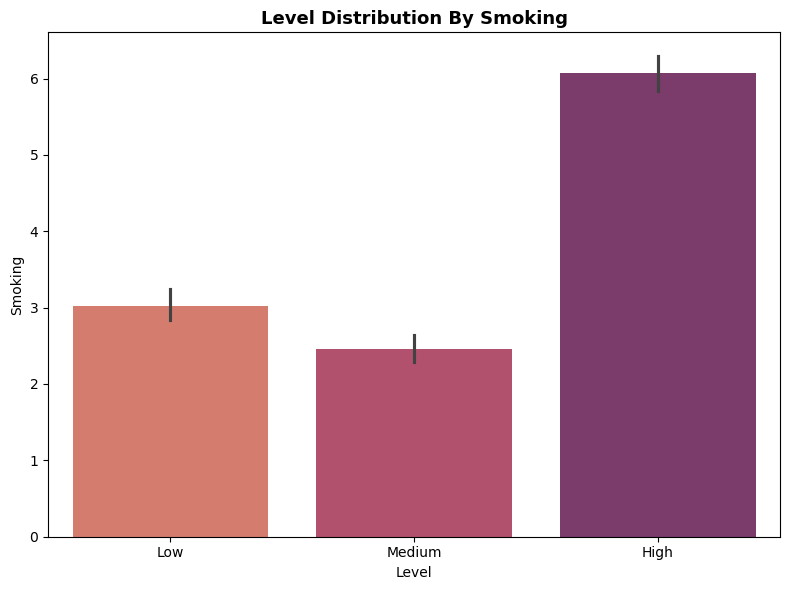

In [12]:
plt.figure(figsize=(8,6))
sns.barplot( x="Level" , y="Smoking", data=df , palette="flare")
plt.title("Level Distribution By Smoking" , fontsize=13 , fontweight="bold")
plt.xlabel("Level")
plt.ylabel("Smoking")
plt.tight_layout()
plt.show()

C:\Users\Funda\AppData\Local\Temp\ipykernel_9380\4198813682.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x="Level" , y="Air Pollution", data=df ,palette="flare" )


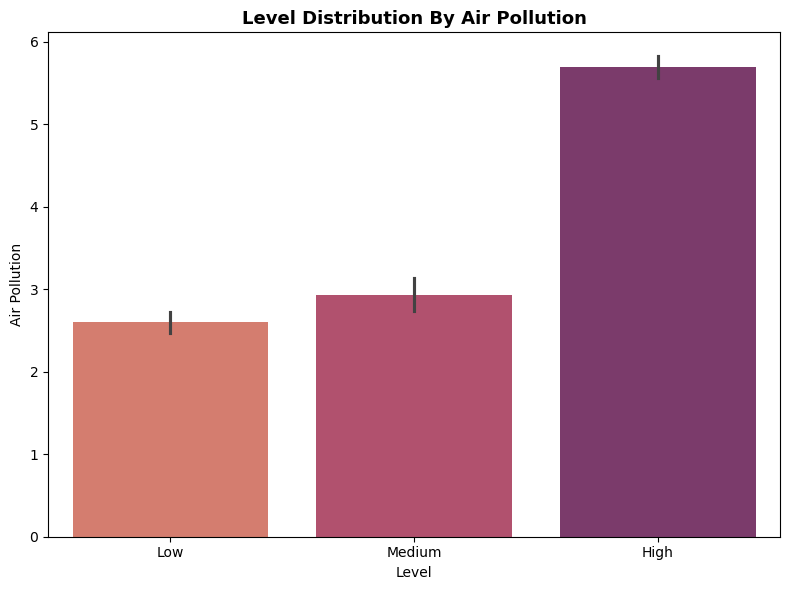

In [13]:
plt.figure(figsize=(8,6))
sns.barplot( x="Level" , y="Air Pollution", data=df ,palette="flare" )
plt.title("Level Distribution By Air Pollution", fontsize=13 , fontweight="bold" )
plt.xlabel("Level")
plt.ylabel("Air Pollution")
plt.tight_layout()
plt.show()

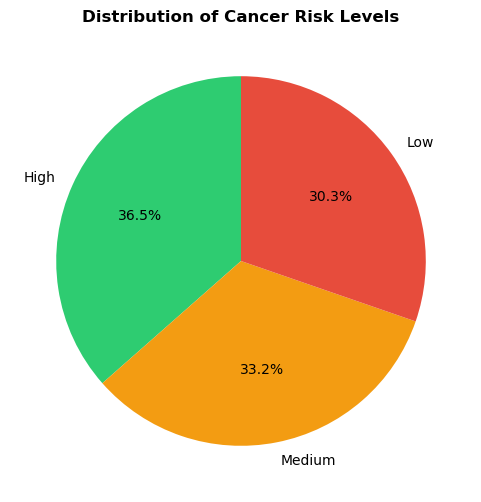

In [14]:
# Show the distribution of patients across risk levels
counts = df['Level'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
plt.title('Distribution of Cancer Risk Levels', fontweight='bold')
plt.show()


In [15]:
# Compare feature averages across cancer risk levels
features = ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards',
            'Genetic Risk', 'chronic Lung Disease', 'Smoking', 'Passive Smoker',
            'Chest Pain', 'Coughing of Blood']
print("Mean feature values by Risk Level:")
df.groupby('Level')[features].mean().round(2)


Mean feature values by Risk Level:


,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Smoking,Passive Smoker,Chest Pain,Coughing of Blood
Level,,,,,,,,,,
High,5.69,6.83,6.62,6.48,6.38,5.83,6.07,6.53,6.39,7.44
Low,2.60,2.23,3.11,3.00,2.73,3.09,3.02,2.63,2.83,2.86
Medium,2.93,4.20,5.44,4.72,4.29,3.96,2.45,3.05,3.75,3.85


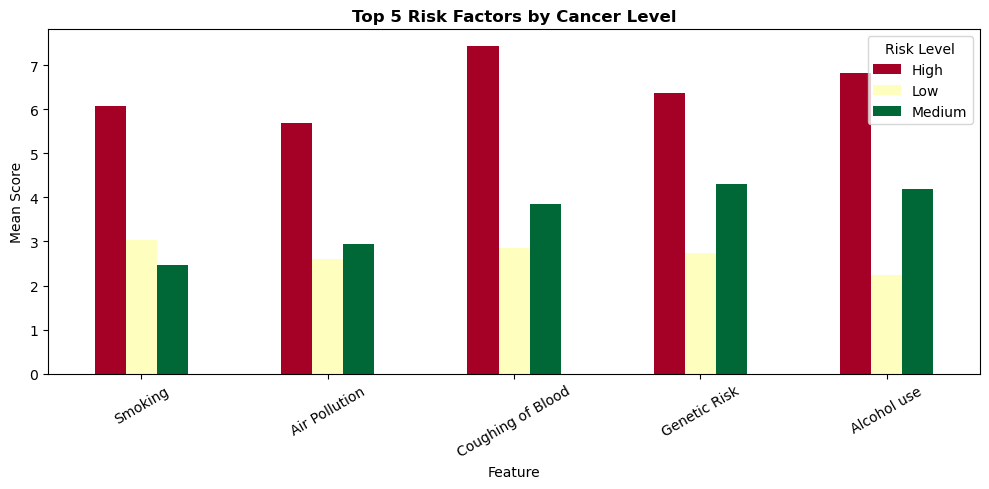

In [ ]:
# Compare the top 5 most impactful features across risk levels
top5 = ['Smoking', 'Air Pollution', 'Coughing of Blood', 'Genetic Risk', 'Alcohol use']
df.groupby('Level')[top5].mean().T.plot(kind='bar', figsize=(10, 5), colormap='RdYlGn')
plt.title('Top 5 Risk Factors by Cancer Level', fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Mean Score')
plt.xticks(rotation=30)
plt.legend(title='Risk Level')
plt.tight_layout()

plt.show()


## 3. Data Cleaning
- Dropped irrelevant IDs (`Patient Id`, `index`) to prevent data leakage.
- Encoded `Level`: `Low: 0`, `Medium: 1`, `High: 2`.
- Removed duplicate patient records.

In [17]:
# Drop unnecessary columns and remove duplicate rows to prevent data leakage
df.drop(["Patient Id", "index"], axis=1, inplace=True, errors='ignore')
df["Level"] = df["Level"].map({"Low": 0, "Medium": 1, "High": 2})

# Remove duplicate patient records
df.drop_duplicates(inplace=True)
print("Unique dataset shape:", df.shape)
df.head()

Unique dataset shape: (152, 24)


,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,0
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,1
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,2
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,2
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,2


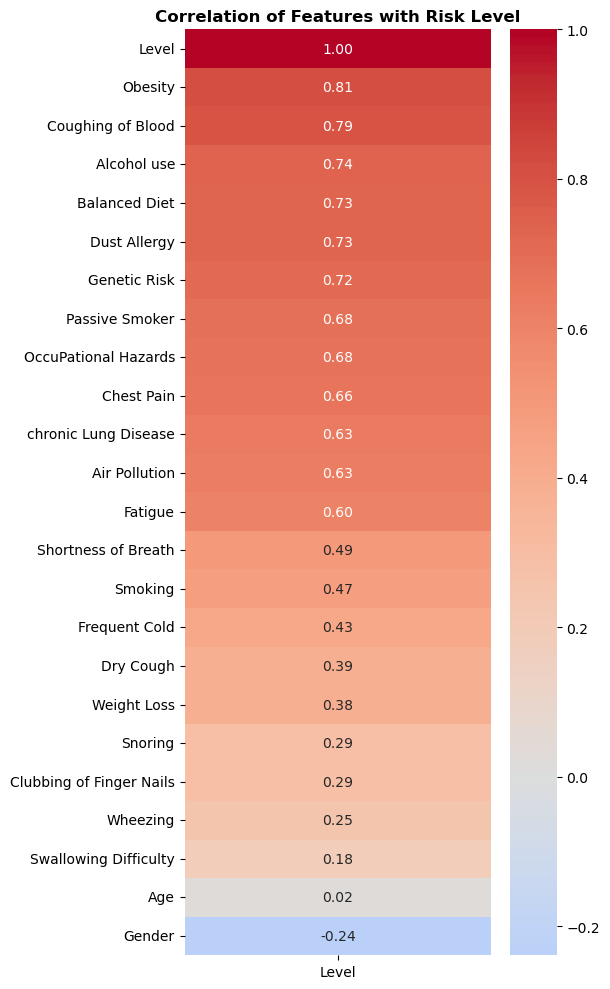

In [19]:
# Correlation of features with cancer risk level
plt.figure(figsize=(6, 10))
corr_target = df.corr()[['Level']].sort_values(by='Level', ascending=False)
sns.heatmap(corr_target, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation of Features with Risk Level', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
X=df.drop("Level",axis=1)
y=df["Level"]

## 4. Model Training & Evaluation
Splitting dataset (80% train / 20% test) and comparing 5 classification models.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (121, 23), Test: (31, 23)


In [22]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

def model_results(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })
    print(f'{name} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

# 1. Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
model_results('Logistic Regression', y_test, y_pred)

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
model_results('Decision Tree', y_test, y_pred)

# 3. Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
model_results('Random Forest', y_test, y_pred)

# 4. Support Vector Machine
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
model_results('Support Vector Machine', y_test, y_pred)

# 5. K-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
model_results('K-Nearest Neighbors', y_test, y_pred)

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
results_df


Logistic Regression -> Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
Decision Tree -> Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
Random Forest -> Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
Support Vector Machine -> Accuracy: 0.9677 | Precision: 0.9704 | Recall: 0.9677 | F1: 0.9675
K-Nearest Neighbors -> Accuracy: 0.9355 | Precision: 0.9454 | Recall: 0.9355 | F1: 0.9341


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000
3,Support Vector Machine,0.9677,0.9704,0.9677,0.9675
4,K-Nearest Neighbors,0.9355,0.9454,0.9355,0.9341


### 🌲 Why Random Forest?
Multiple models achieved **1.0 (100%) accuracy**. We chose **Random Forest** for deployment because:
1. **Less Overfitting:** Unlike a single Decision Tree, it uses ensemble averaging to prevent memorizing data.
2. **Better Generalization:** Handles unseen, noisy real-world patient data much more reliably.
3. **Robustness:** Averages multiple trees, making it less sensitive to slight variations in symptoms.


## 5. Risk Assessment Mini-App
Interactive tool to predict patient risk based on 1-8 symptom inputs.

In [23]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. Train Best Model (Random Forest)
model = RandomForestClassifier(random_state=42, n_jobs=1)
model.fit(X_train, y_train)

# 2. Risk Level Descriptions & Recommendations
risk_info = {
    0: ("🟢 Low Risk", "Maintain healthy lifestyle habits and routine clinical check-ups."),
    1: ("🟡 Medium Risk", "Consult a pulmonologist and reduce environmental risk exposures."),
    2: ("🔴 High Risk", "Immediate clinical screening and specialist consultation required!")
}

# 3. Prediction & Detailed Reporting Function
def predict_risk(patient_data):
    df_input = pd.DataFrame([patient_data])
    pred = int(model.predict(df_input)[0])
    level, advice = risk_info.get(pred, ("Unknown", "Consult a physician."))
    
    print("\n" + "=" * 55)
    print("🏥 LUNG CANCER RISK ASSESSMENT REPORT")
    print("=" * 55)
    
    # Display Entered Patient Input Values
    print("\n📋 PATIENT INPUT FEATURES:")
    print("-" * 55)
    for col, val in patient_data.items():
        print(f"  • {col:<26}: {val}")
    print("-" * 55)
    
    # Display Prediction & Clinical Advice
    print(f"\n🎯 Prediction Result : {level}")
    print(f"💡 Clinical Advice   : {advice}")
    print("=" * 55 + "\n")
    return pred

# 4. Smart Interactive Mini-App
def run_app():
    print("📋 Enter patient values (Press Enter to accept default values):")
    print("=" * 55)
    patient = {}
    
    for col in X.columns:
        if col == "Age":
            val = input(f"- {col} (e.g. 18-80) [default 45]: ").strip()
            patient[col] = int(val) if val else 45
        elif col == "Gender":
            val = input(f"- {col} (1: Male, 2: Female) [default 1]: ").strip()
            patient[col] = int(val) if val else 1
        else:
            val = input(f"- {col} (Severity scale 1-8) [default 3]: ").strip()
            patient[col] = int(val) if val else 3
            
    predict_risk(patient)

# Launch Mini-App
run_app()


📋 Enter patient values (Press Enter to accept default values):

🏥 LUNG CANCER RISK ASSESSMENT REPORT

📋 PATIENT INPUT FEATURES:
-------------------------------------------------------
  • Age                       : 35
  • Gender                    : 1
  • Air Pollution             : 5
  • Alcohol use               : 6
  • Dust Allergy              : 4
  • OccuPational Hazards      : 5
  • Genetic Risk              : 3
  • chronic Lung Disease      : 2
  • Balanced Diet             : 4
  • Obesity                   : 4
  • Smoking                   : 5
  • Passive Smoker            : 1
  • Chest Pain                : 6
  • Coughing of Blood         : 5
  • Fatigue                   : 4
  • Weight Loss               : 2
  • Shortness of Breath       : 5
  • Wheezing                  : 4
  • Swallowing Difficulty     : 3
  • Clubbing of Finger Nails  : 4
  • Frequent Cold             : 7
  • Dry Cough                 : 6
  • Snoring                   : 2
---------------------------------